In [2]:
from google.colab import drive
drive.mount('/content/drive')

%run '/content/drive/MyDrive/Repos/MachineLearning-ML001/helper/helper.ipynb'

Mounted at /content/drive


# Building a Decision Tree

Decision trees are powerful algorithms that build complex decision boundaries by dividing the feature space into rectangles.

### Key Characteristics
* **Axis-Parallel Boundaries:** The algorithm splits data using perpendicular lines, resulting in rectangular decision regions.
* **No Feature Scaling Required:** Unlike many other machine learning algorithms, decision trees do not require feature scaling (standardization or normalization) to work effectively, though you might still use it for visualization purposes.
* **Prone to Overfitting:** The deeper a decision tree grows, the more complex the decision boundary becomes. This can easily lead to overfitting the training data.

### Training the Model
In scikit-learn, you can control overfitting by limiting the depth of the tree. A common approach is setting a maximum depth (e.g., `max_depth=4`) and using the **Gini impurity** as the criterion for splitting nodes.



In [3]:
iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y)

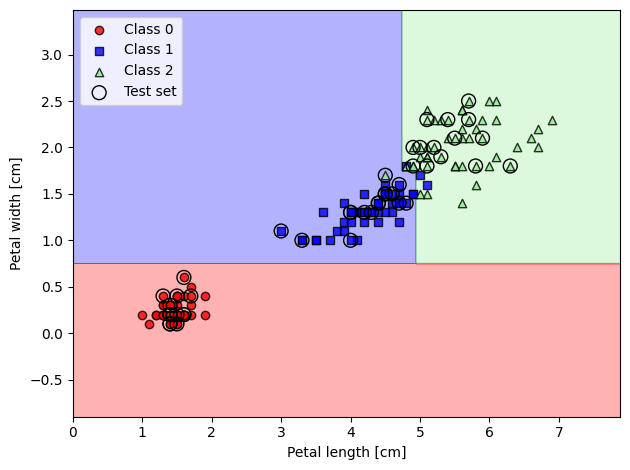

In [4]:
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=1)
tree_model.fit(X_train, y_train)

X_combined = np.vstack((X_train, X_test))
y_combined = np.hstack((y_train, y_test))

plot_decision_regions(X_combined,
                       y_combined,
                       classifier=tree_model,
                       test_idx=range(105, 150))
plt.xlabel('Petal length [cm]')
plt.ylabel('Petal width [cm]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

### Visualizing the Tree
Scikit-learn provides convenient tools to visualize both the decision boundaries and the internal logic of the tree model.

**Visualizing the Tree Structure:**
You can use `sklearn.tree.plot_tree` to generate a flowchart-like visualization of the model.

### Interpreting the Tree Plot
When reading the outputted decision tree figure:
* **Branches:** The left branch always corresponds to **"True"** and the right branch corresponds to **"False"** for the given splitting criterion at that node.
* **Node Information:** Each node displays the split condition (if not a leaf), the current Gini impurity, the number of samples, and the distribution of those samples across the classes.
* **Purity:** A node with a Gini impurity of `0.0` is completely "pure," meaning it only contains samples from a single class. For example, in the Iris dataset, an initial split of `sepal width <= 0.75 cm` might perfectly isolate the `Iris-setosa` class into a pure left child node.

### Handling Overfitting & Pruning
If your model is overfitting, you need to restrict its complexity:
1.  **Pre-pruning (Manual):** Scikit-learn does not support manual post-pruning. Instead, you can pre-prune the tree by adjusting hyperparameters during training, such as lowering the `max_depth` (e.g., changing it from 4 to 3).
2.  **Cost Complexity Pruning (Automatic):** Scikit-learn offers an automatic cost complexity post-pruning procedure for a more advanced, automated approach to reducing tree size.

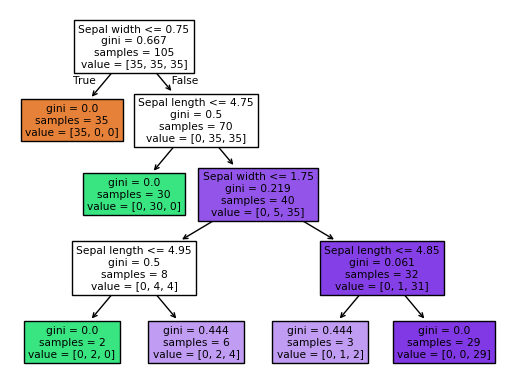

In [5]:
from sklearn import tree
feature_names = ['Sepal length', 'Sepal width',
                  'Petal length', 'Petal width']
tree.plot_tree(tree_model,
                feature_names=feature_names,
                filled=True)
plt.show()